In [1]:
import pandas as pd
import numpy as np

from math import isnan
import multiprocessing as mp
import matplotlib.pyplot as plt
import json
from protocols import utils, functions, graphs
from matplotlib_venn import venn2
from functools import partial
from joblib import Memory
from multiprocessing import Pool, get_context
import multiprocessing as mp

import gumpy


%load_ext autoreload
%autoreload 2

# Compare contents of WHOv1 vs catomatic-1, as trained on same data

The comparison is complicated by the fact catomatic-1 does not contain rules and WHOv1 does - its an assymetric comparison.

We want to show the effect of removing rules from WHOv1 as well as the effect of the ruels.

The only way to determine how many variants are captured by a generlisable rule, is to constrain the application of the rules to the training set. 

The function expand_catalogue_pair, does this by applying both catalogues to the training set and counting how many variants have definitive predictions.

In [2]:
def load_who_catalogue(path):
    #Prep data for comparisons:
    who = pd.read_csv(path)
    who['EVIDENCE'] = who['EVIDENCE'].apply(utils.str_to_dict)
    who['GENBANK_REFERENCE'] = 'NC00962.3'
    who['CATALOGUE_VERSION'] = 0
    who['CATALOGUE_NAME'] = '-'
    #filter out default rules
    who = who[~who['EVIDENCE'].apply(lambda x: isinstance(x, dict) and 'reporting_rule' in x)]
    return who

who = load_who_catalogue('catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv')
who['solo_R'] = who['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'Present_R'))
who['solo_S'] = who['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'Present_S'))
who['TOTAL'] = who['solo_R'] + who['solo_S']
who['PROPORTION'] = who['solo_R']/(who['solo_R']+who['solo_S'])
who['CONFIDENCE'] = who.apply(utils.wilson_ci, R_col='solo_R', S_col='solo_S', axis=1)
u_who = who[~who.PREDICTION.isin(['R','S'])]
who = who[who.PREDICTION.isin(['R','S'])]

In [3]:
who[who.MUTATION==("pncA@*_indel")]

,GENBANK_REFERENCE,CATALOGUE_NAME,CATALOGUE_VERSION,CATALOGUE_GRAMMAR,PREDICTION_VALUES,DRUG,MUTATION,PREDICTION,SOURCE,EVIDENCE,OTHER,Unnamed: 0,solo_R,solo_S,TOTAL,PROPORTION,CONFIDENCE
1468,NC00962.3,-,0,GARC1,RUS,PZA,pncA@*_indel,R,{},{},{},NaN,NaN,NaN,NaN,NaN,"[nan, nan]"


In [4]:
def load_who_catalogue(path):
    #Prep data for comparisons:
    who = pd.read_csv(path)
    who['EVIDENCE'] = who['EVIDENCE'].apply(utils.str_to_dict)
    who['GENBANK_REFERENCE'] = 'NC00962.3'
    who['CATALOGUE_VERSION'] = 0
    who['CATALOGUE_NAME'] = '-'
    #filter out default rules
    who = who[~who['EVIDENCE'].apply(lambda x: isinstance(x, dict) and 'reporting_rule' in x)]
    return who

who = load_who_catalogue('catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv')
who['solo_R'] = who['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'Present_R'))
who['solo_S'] = who['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'Present_S'))
who['TOTAL'] = who['solo_R'] + who['solo_S']
who['PROPORTION'] = who['solo_R']/(who['solo_R']+who['solo_S'])
who['CONFIDENCE'] = who.apply(utils.wilson_ci, R_col='solo_R', S_col='solo_S', axis=1)
u_who = who[~who.PREDICTION.isin(['R','S'])]
who = who[who.PREDICTION.isin(['R','S'])]

def load_catomatic_catalogues(opt_path, base_path):
    """Load and process catomatic catalogues from optimal parameter settings."""
    opt_df = pd.read_csv(opt_path)
    valid_drugs = opt_df

    # Load catalogue files based on optimal settings
    catalogue_dfs = valid_drugs.apply(
        lambda row: pd.read_csv(
            f"{base_path}/{row['DRUG'].lower()}/bg_{row['BACKGROUND_RATE']}_p_{row['conf_level']}_FRS_0.1.csv"
        ),
        axis=1
    ).tolist()

    cat_df = pd.concat(catalogue_dfs)
    cat_df['CATALOGUE_VERSION'] = 0
    cat_df['CATALOGUE_NAME'] = '-'

    # Parse evidence
    cat_df['EVIDENCE'] = cat_df['EVIDENCE'].apply(utils.str_to_dict)
    cat_df = cat_df[~cat_df['EVIDENCE'].apply(lambda x: isinstance(x, dict) and 'default_rule' in x)]

    # Extract key metrics
    cat_df['solo_R'] = cat_df['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'solo_contingency', 0, 0))
    cat_df['solo_S'] = cat_df['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'solo_contingency', 0, 1))
    cat_df['TOTAL'] = cat_df['solo_R'] + cat_df['solo_S']
    cat_df['PROPORTION'] = cat_df['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'proportion'))
    cat_df['CONFIDENCE'] = cat_df['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'confidence'))

    # Keep only R and S predictions
    unknown = cat_df[~cat_df.PREDICTION.isin(['R', 'S'])]
    cat_df = cat_df[cat_df.PREDICTION.isin(['R', 'S'])]

    return cat_df, unknown

# Load both catalogue sets
cat, u_cat = load_catomatic_catalogues(
    'results/grid_search/opt_cats_MTBC-CRyPTICv1.1.1-2025.8.csv',
    './catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search'
)

valid_drugs = cat.DRUG.unique()
valid_drugs = np.delete(valid_drugs, np.where(valid_drugs == 'CIP'))

catalogue_palette = {
    "catomatic_v1": "#70c0b3", 
    "catomatic_v3": "#018571",  
    "WHOv1": "#d5b477",        
    "WHOv2": "#a6611a",        
}

In [5]:
valid_drugs_filt = [i for i in valid_drugs if i not in ['PZA', 'ETH']]

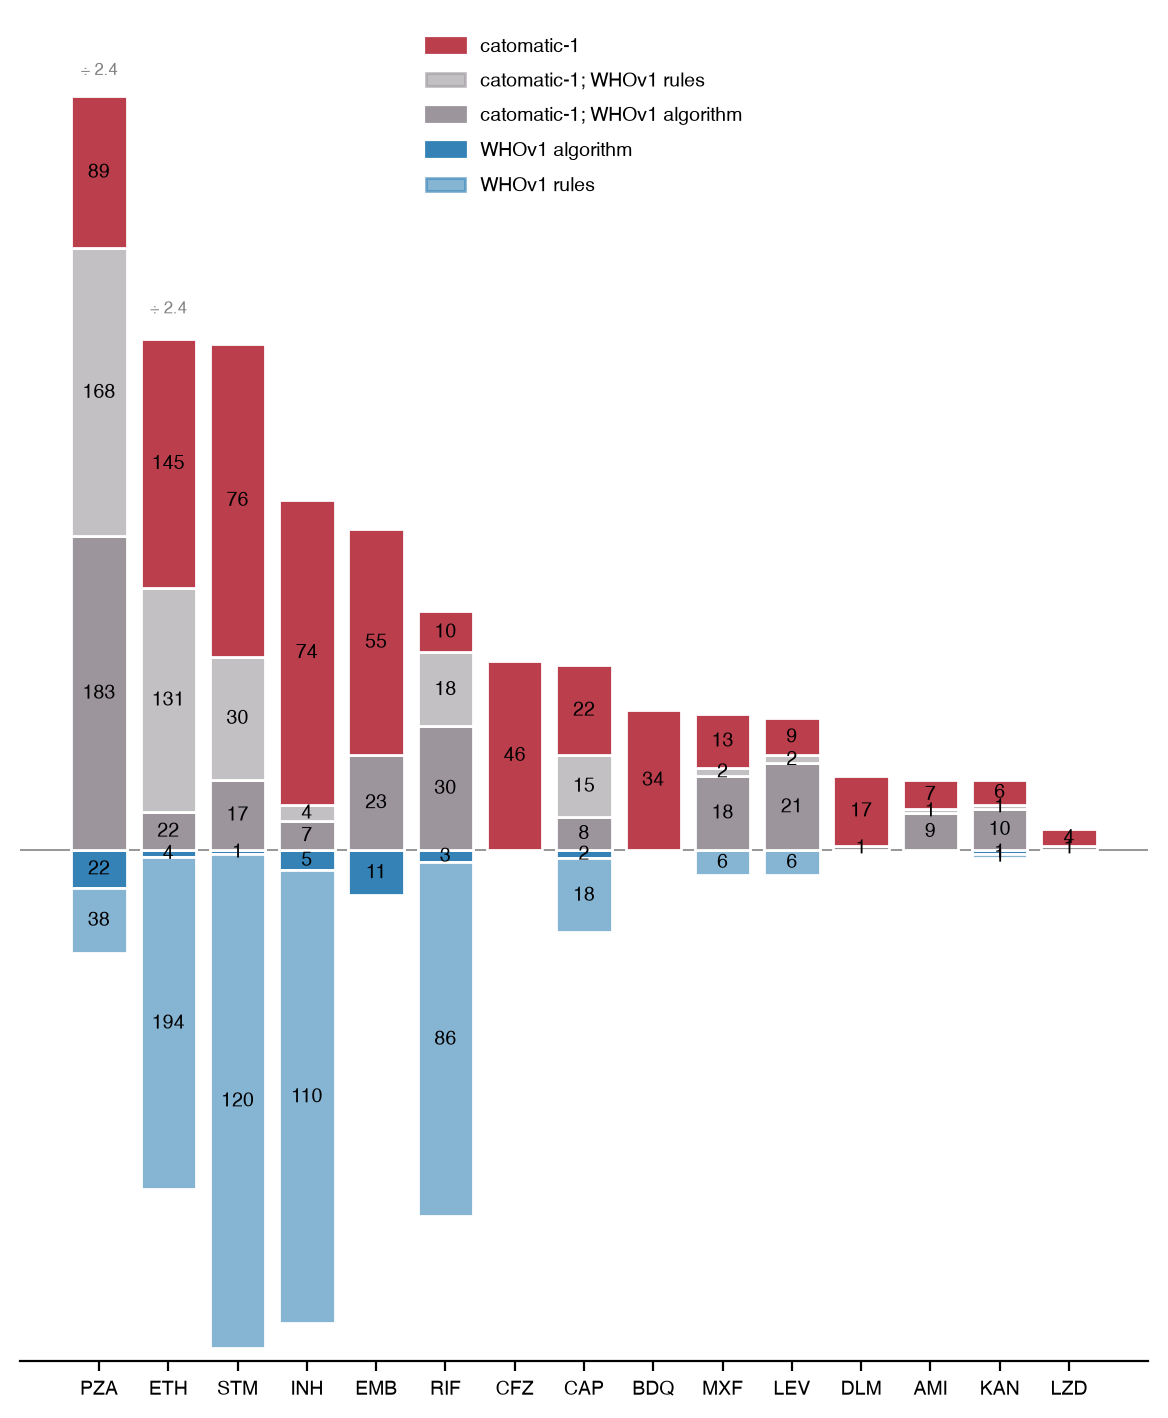

In [6]:
expanded_catalogues = functions.expand_catalogue_pair(cat, who, valid_drugs, 'RUS', ('cat', 'who'), who_cat='WHOv1')
graphs.plot_floating_bars(expanded_catalogues, valid_drugs, figsize=(5.85, 7.1), legend=True)

In [7]:
expanded_catalogues

{'RIF': {'cat':    GENBANK_REFERENCE CATALOGUE_NAME  CATALOGUE_VERSION CATALOGUE_GRAMMAR  \
  0          NC00962.3              -                  0             GARC1   
  1          NC00962.3              -                  0             GARC1   
  2          NC00962.3              -                  0             GARC1   
  3          NC00962.3              -                  0             GARC1   
  4          NC00962.3              -                  0             GARC1   
  5          NC00962.3              -                  0             GARC1   
  6          NC00962.3              -                  0             GARC1   
  7          NC00962.3              -                  0             GARC1   
  8          NC00962.3              -                  0             GARC1   
  9          NC00962.3              -                  0             GARC1   
  10         NC00962.3              -                  0             GARC1   
  11         NC00962.3              -             

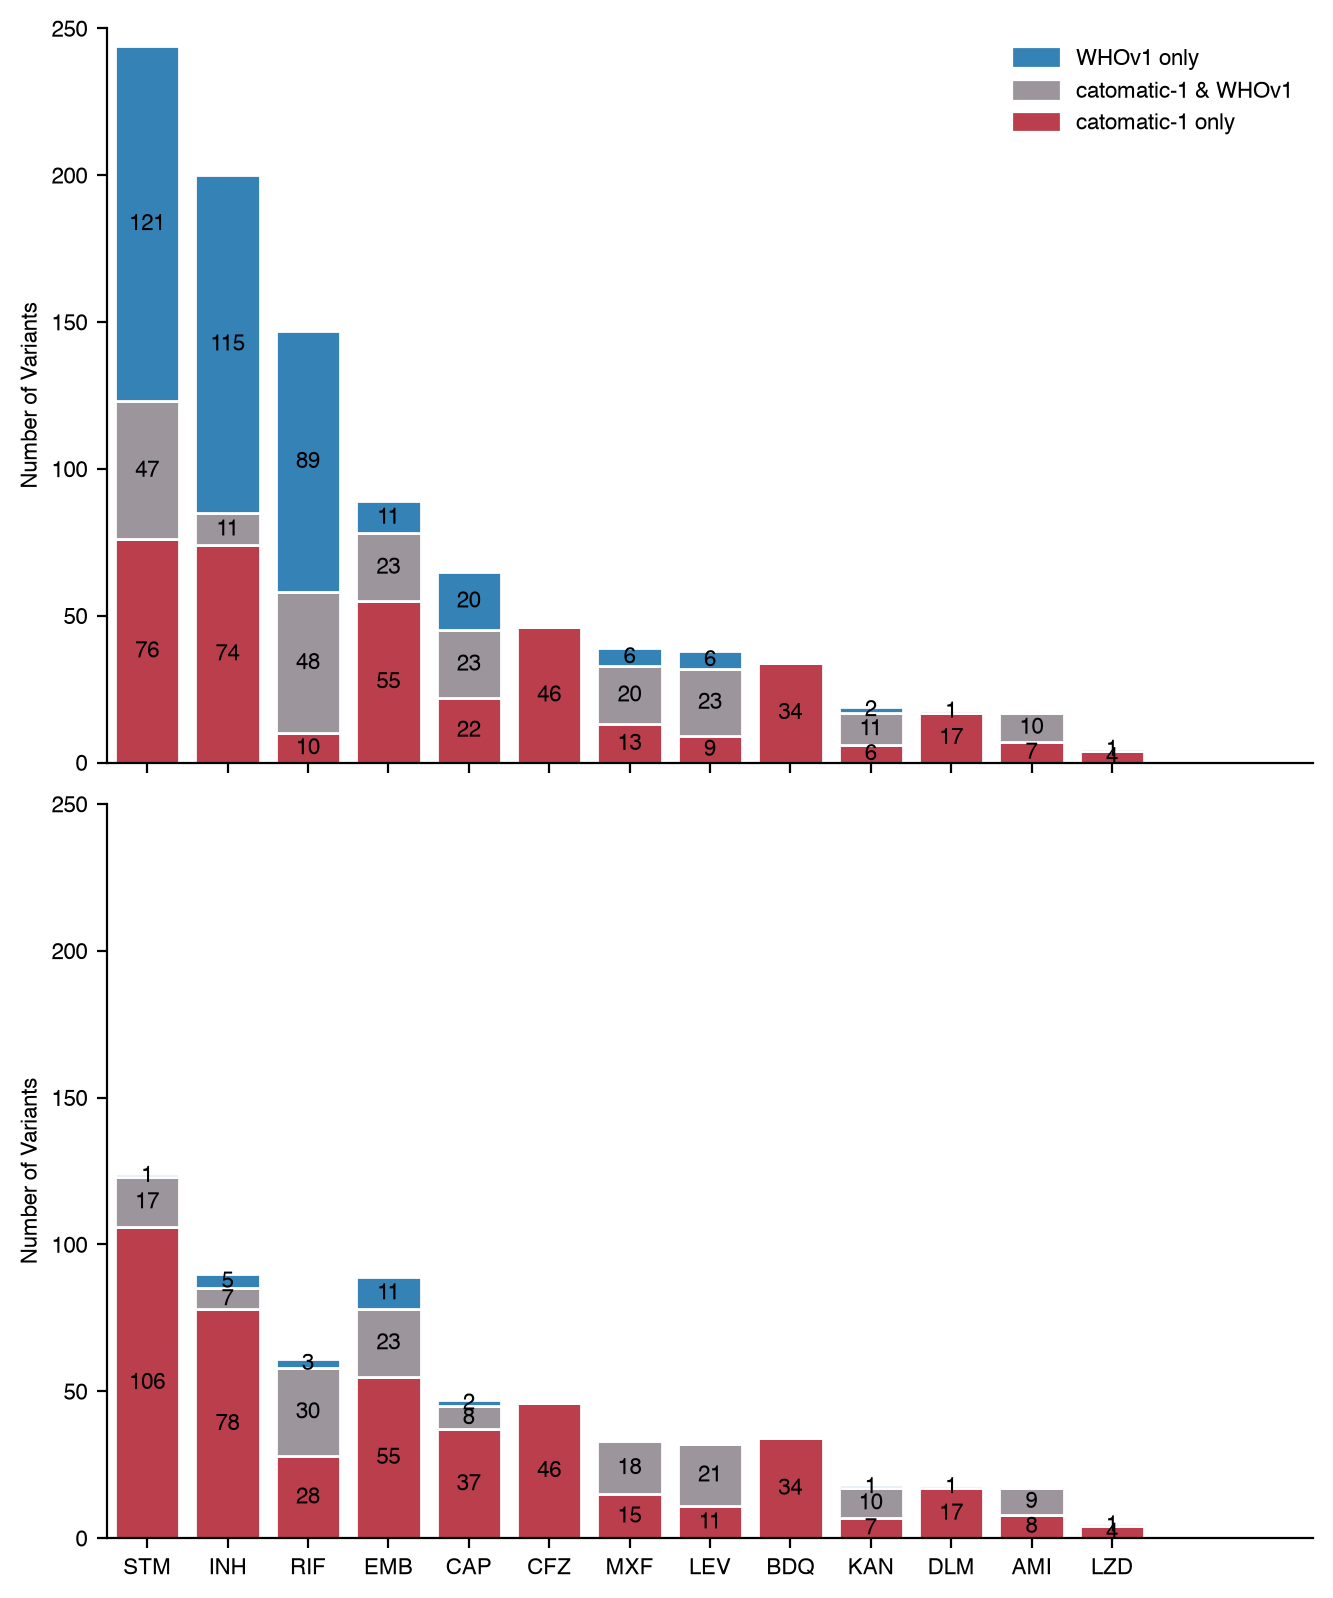

In [ ]:
graphs.plot_bar_charts(
expanded_catalogues, [d for d in valid_drugs if d not in ["PZA", "ETH"]], figsize=(6.69, 8), legend=True, output_path='./figs/main/discordance_bars.pdf'
)

In [10]:
cryptic_tables_path = "data/cryptic-tables-v3.4.0/"

with open("data/drug_to_genes.json", "r") as f:
    drug_genes = json.load(f)


def process_pair_coverage(args):
    """
    Build pair coverages for one drug.
    """
    drug, genes, cat, who = args

    mutations = functions.prep_mutations(
        "data/mutations-v3.4.0/",
        genes,
        version="v3.4.0",
        mut_path=cryptic_tables_path + "MUTATIONS.parquet",
        var_path=cryptic_tables_path + "VARIANTS.parquet",
        train=True,
    )

    phenotypes = functions.prep_phenotypes(
        drug,
        cryptic_tables_path + "DST_MEASUREMENTS.parquet",
        cryptic_tables_path + "WGS_SAMPLES.parquet",
        version="v3.4.0",
        validation=False,
    )

    pair_cov = functions.expand_pair_coverages(
        cat, who, mutations, phenotypes, drug, "RUS", who_cat="WHOv1"
    )

    return drug, pair_cov


def parallel_pair_coverages(drug_genes, cat, who, valid_drugs, n_cores=4):
    """
    Compute pair coverages for all valid drugs in parallel.
    """
    # Build tasks
    tasks = [(drug, drug_genes[drug]["genes"], cat, who) for drug in valid_drugs]

    ctx = mp.get_context("fork")   # Linux/Mac
    num_workers = min(n_cores, len(tasks))

    with ctx.Pool(num_workers) as pool:
        results = list(pool.imap(process_pair_coverage, tasks))

    # Reassemble dictionary
    pair_coverages = {drug: pair_cov for drug, pair_cov in results}

    return pair_coverages


pair_coverages = parallel_pair_coverages(drug_genes, cat, who, valid_drugs, n_cores=8)
expanded_catalogues = functions.expand_catalogue_pair(cat, who, valid_drugs, 'RUS', ('cat', 'who'), who_cat='WHOv1')


Process ForkPoolWorker-9:
Process ForkPoolWorker-10:
Process ForkPoolWorker-12:
Process ForkPoolWorker-16:
Process ForkPoolWorker-15:
Process ForkPoolWorker-13:
Process ForkPoolWorker-14:
Process ForkPoolWorker-11:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/dylanadlard/miniforge3/envs/cryptic-catalogues-25/lib/python3.14/multiprocessing/process.py", line 320, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/Users/dylanadlard/miniforge3/envs/cryptic-catalogues-25/lib/python3.14/multiprocessing/process.py", line 320, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/Users/dylanadlard/miniforge3/envs/cryptic-catalogues-25/lib/python3.14/multiprocessing/process.py", line 320, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/Users/dylanadlard/miniforge3/envs/cryptic-catalogues-25/lib/python3.14/multiprocessing/process.py", line 320, in _bootstrap
    self.run()
    ~~~~

KeyboardInterrupt: 

In [ ]:
drug_genes

{'RIF': {'genes': ['rpoB'], 'phylogenetic': []},
 'INH': {'genes': ['katG', 'inhA', 'ahpC', 'fabG1'], 'phylogenetic': []},
 'EMB': {'genes': ['embA', 'embB'], 'phylogenetic': []},
 'PZA': {'genes': ['pncA'], 'phylogenetic': []},
 'LEV': {'genes': ['gyrA', 'gyrB'],
  'phylogenetic': ['gyrA@S95T', 'gyrA@E21Q', 'gyrA@G668D', 'gyrB@M291I']},
 'MXF': {'genes': ['gyrA', 'gyrB'],
  'phylogenetic': ['gyrA@S95T', 'gyrA@E21Q', 'gyrA@G668D', 'gyrB@M291I']},
 'BDQ': {'genes': ['Rv0678', 'pepQ', 'atpE'], 'phylogenetic': []},
 'LZD': {'genes': ['rplC'], 'phylogenetic': []},
 'CFZ': {'genes': ['Rv0678', 'pepQ'], 'phylogenetic': []},
 'DLM': {'genes': ['ddn', 'dprE1'], 'phylogenetic': []},
 'AMI': {'genes': ['eis', 'rrs'], 'phylogenetic': []},
 'STM': {'genes': ['gid', 'rpsL', 'rrs'], 'phylogenetic': []},
 'ETH': {'genes': ['ethA', 'fabG1', 'inhA'], 'phylogenetic': []},
 'KAN': {'genes': ['eis', 'rrs'], 'phylogenetic': []},
 'CAP': {'genes': ['rrs', 'tlyA'], 'phylogenetic': []}}

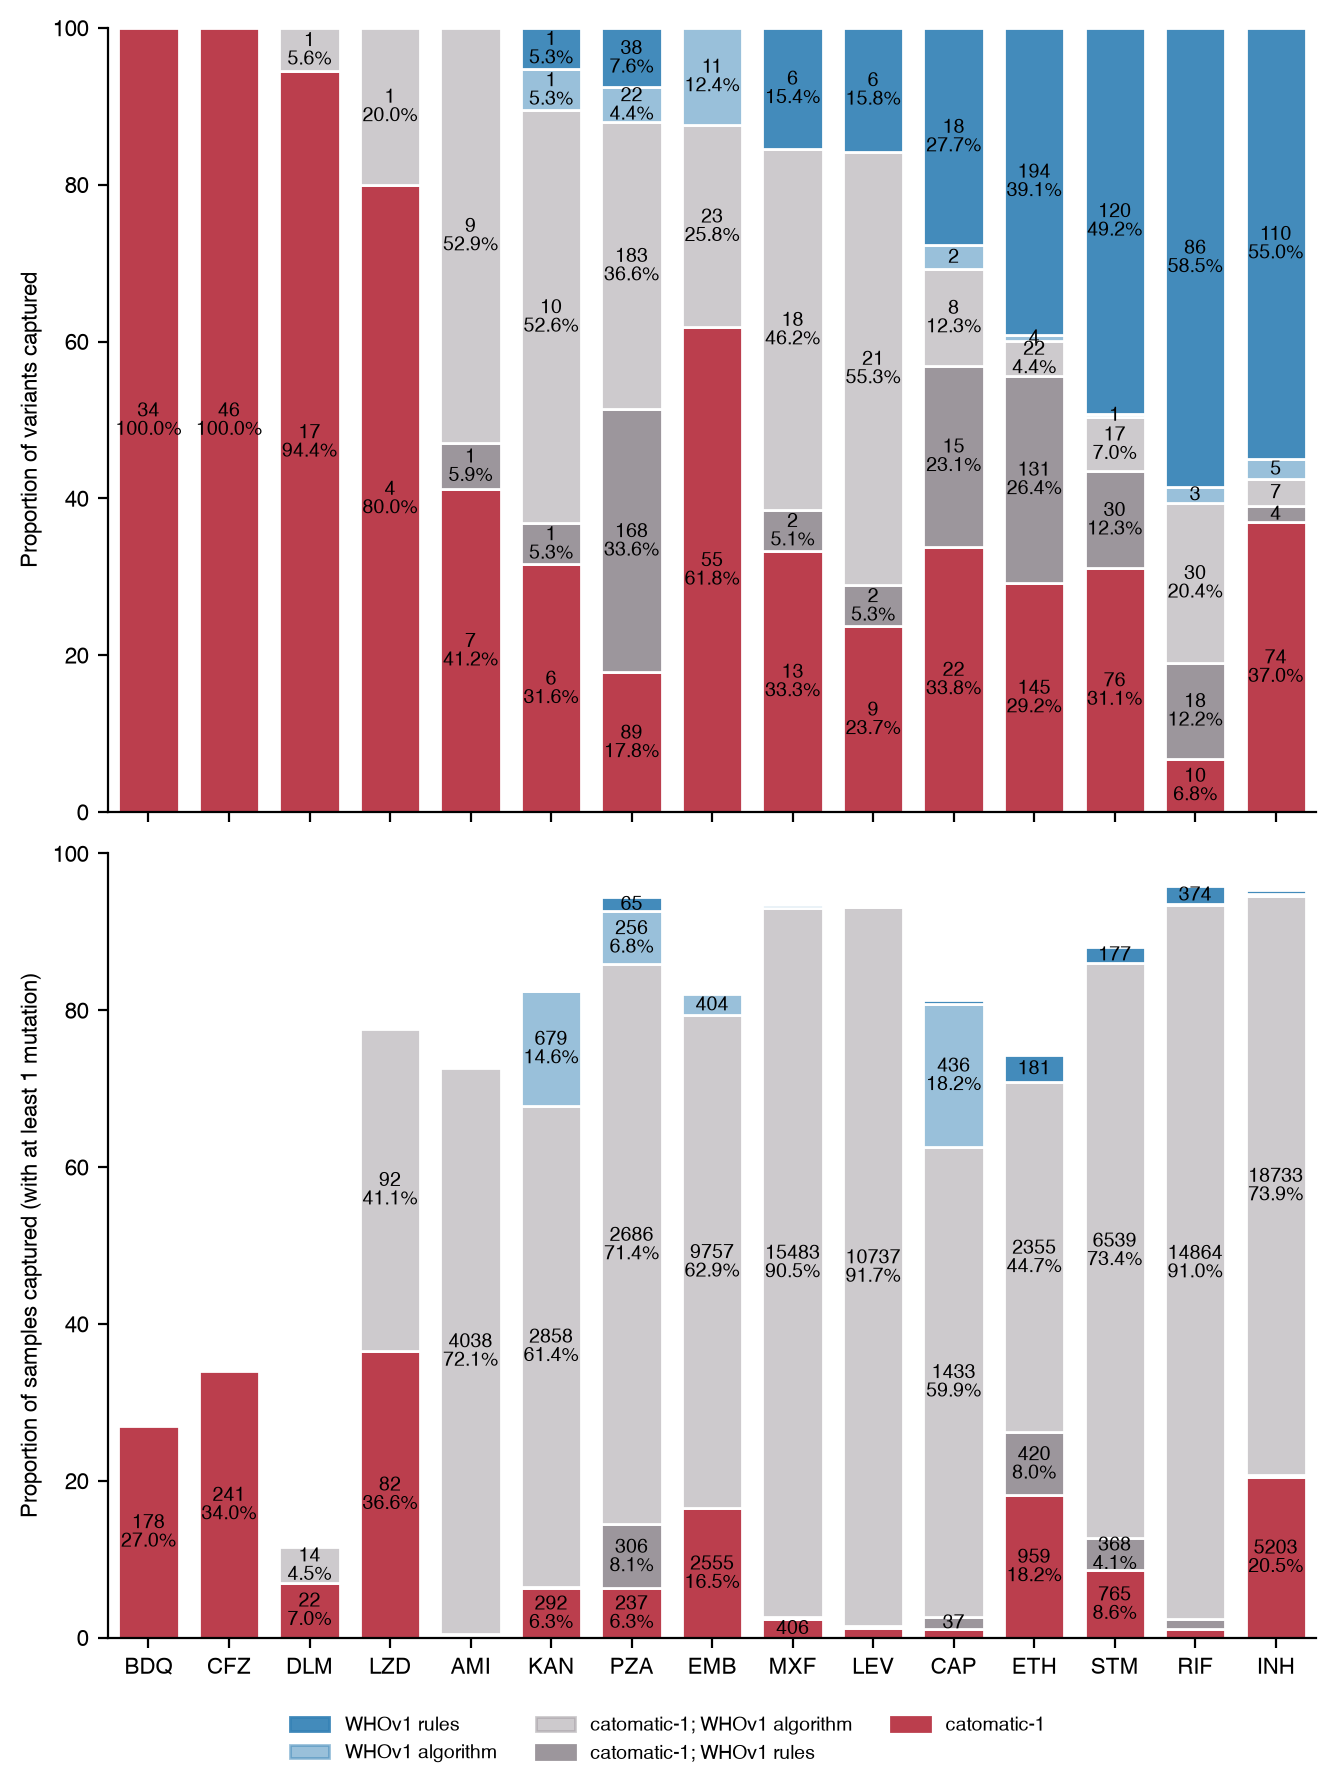

In [ ]:
graphs.plot_stacked_percentage_bars(expanded_catalogues, pair_coverages, valid_drugs, legend=True, figsize=(6.69, 8.5))

## Summary table including rules

In [ ]:
expanded_catalogues = functions.expand_catalogue_pair(cat, who, valid_drugs, 'RUS', ('cat', 'who'), who_cat='WHOv1')
all_drugs_merged = pd.concat(expanded_catalogues[drug]['merged'] for drug in valid_drugs)
suffixes = ('cat', 'who')
all_drugs_merged['PREDICTION_PAIR'] = all_drugs_merged.apply(utils.classify_predictions, axis=1, args=(suffixes,))
all_drugs_merged['DRUG'] = all_drugs_merged['DRUG_who'].combine_first(all_drugs_merged['DRUG_cat'])

summary_table = (
    all_drugs_merged.drop_duplicates(['DRUG', 'MUTATION']).groupby(['DRUG', 'PREDICTION_PAIR'])
    .size()
    .unstack(fill_value=0)  # Pivot table to create columns for prediction pairs
    .reset_index()  # Resets the index, moving 'PREDICTION_PAIR' into a column
)

summary_table.rename(columns={'DRUG': 'DRUG'}, inplace=True)
summary_table['total'] = summary_table.drop(columns=['DRUG']).sum(axis=1)
summary_table.columns.name = None

print ('Prediction pairs comparing catomatic_v1 with WHOv1, including rules:')
summary_table.to_csv('figs/discordance/summary_pairs_w_rules.csv')
summary_table

Prediction pairs comparing catomatic_v1 with WHOv1, including rules:


,DRUG,R.R,R.S,R.U,S.R,S.S,S.U,U.R,U.S,total
0,AMI,4,0,7,0,6,0,0,0,17
1,BDQ,0,0,34,0,0,0,0,0,34
2,CAP,21,0,22,0,2,0,18,2,65
3,CFZ,0,0,46,0,0,0,0,0,46
4,DLM,1,0,17,0,0,0,0,0,18
5,EMB,12,0,8,0,11,47,3,8,89
6,ETH,153,0,145,0,0,0,198,0,496
7,INH,10,0,52,0,1,22,112,3,200
8,KAN,8,0,3,0,3,3,0,2,19
9,LEV,10,0,3,0,13,6,4,2,38


In [ ]:
def nan_friendly_filter(series, value):
    if pd.isna(value):
        return series.isna()
    else:
        return series == value

# Example usage:
drug = "STM"
cat_pheno = 'R'
who_pheno = np.nan
#np.nan

all_drugs_merged[
    (all_drugs_merged.DRUG==drug) &
    nan_friendly_filter(all_drugs_merged.PREDICTION_who, who_pheno) &
    nan_friendly_filter(all_drugs_merged.PREDICTION_cat, cat_pheno)
]

,GENBANK_REFERENCE_cat,CATALOGUE_NAME_cat,CATALOGUE_VERSION_cat,CATALOGUE_GRAMMAR_cat,PREDICTION_VALUES_cat,DRUG_cat,MUTATION,PREDICTION_cat,SOURCE_cat,EVIDENCE_cat,...,EVIDENCE_who,OTHER_who,Unnamed: 0,solo_R_who,solo_S_who,TOTAL_who,PROPORTION_who,CONFIDENCE_who,PREDICTION_PAIR,DRUG
0,NC00962.3,-,0.0,GARC1,RUS,STM,gid@-33_del_t,R,{},"{'proportion': 0.5714285714285714, 'confidence...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM
146,NC00962.3,-,0.0,GARC1,RUS,STM,gid@A119D,R,{},"{'proportion': 0.5, 'confidence': [0.221259986...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM
147,NC00962.3,-,0.0,GARC1,RUS,STM,gid@A133P,R,{},"{'proportion': 0.6, 'confidence': [0.272483171...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM
149,NC00962.3,-,0.0,GARC1,RUS,STM,gid@A138E,R,{},"{'proportion': 0.6, 'confidence': [0.272483171...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM
150,NC00962.3,-,0.0,GARC1,RUS,STM,gid@A138P,R,{},"{'proportion': 0.8, 'confidence': [0.435292553...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266,NC00962.3,-,0.0,GARC1,RUS,STM,rrs@a514t,R,{},"{'proportion': 0.9090909090909091, 'confidence...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM
267,NC00962.3,-,0.0,GARC1,RUS,STM,rrs@a907c,R,{},"{'proportion': 1.0, 'confidence': [0.425030609...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM
268,NC00962.3,-,0.0,GARC1,RUS,STM,rrs@a907t,R,{},"{'proportion': 1.0, 'confidence': [0.425030609...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM
271,NC00962.3,-,0.0,GARC1,RUS,STM,rrs@c513t,R,{},"{'proportion': 1.0, 'confidence': [0.425030609...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM


## Mutaton comparison inlcuding rules

To create a mutation-level comparison table between WHOv1, WHOv1 algorithm, catomatic-1 and catomatic-2 (finished further down in notebook)

In [ ]:
expanded_catalogues = functions.expand_catalogue_pair(
    cat, who, valid_drugs, 'RUS', ('cat', 'who'), who_cat='WHOv1'
)

all_drugs_merged = pd.concat(
    (expanded_catalogues[drug]['merged'] for drug in valid_drugs),
    ignore_index=True
)

suffixes = ('cat', 'who')
all_drugs_merged['PREDICTION_PAIR'] = all_drugs_merged.apply(
    utils.classify_predictions, axis=1, args=(suffixes,)
)

all_drugs_merged['DRUG'] = all_drugs_merged['DRUG_who'].combine_first(
    all_drugs_merged['DRUG_cat']
)


# Prefer rows where both sides are present, then keep the first one.
all_drugs_merged['_both_present'] = (
    all_drugs_merged['PREDICTION_cat'].notna() &
    all_drugs_merged['PREDICTION_who'].notna()
)

resolved = (
    all_drugs_merged
    .sort_values(['DRUG', 'MUTATION', '_both_present'], ascending=[True, True, False])
    .drop_duplicates(['DRUG', 'MUTATION'], keep='first')
    .copy()
)

# Split "R.U" into two columns
resolved[['cat', 'who']] = resolved['PREDICTION_PAIR'].str.split('.', n=1, expand=True)

mutation_table = (
    resolved[['DRUG', 'MUTATION', 'cat', 'who']]
    .sort_values(['DRUG', 'MUTATION'])
    .reset_index(drop=True)
)

cat1_who_rules_mutations = mutation_table
cat1_who_rules_mutations

,DRUG,MUTATION,cat,who
0,AMI,eis@805_del_ac,S,S
1,AMI,eis@E199A,R,U
2,AMI,eis@L235R,R,U
3,AMI,eis@L331R,R,U
4,AMI,eis@V163I,S,S
...,...,...,...,...
1952,STM,rrs@c513t,R,U
1953,STM,rrs@c517t,R,R
1954,STM,rrs@c905a,R,U
1955,STM,rrs@g878a,R,R


In [ ]:
#catomatic2

cat2, u_cat2_all = load_catomatic_catalogues(
    'results/grid_search/opt_cats_MTBC-CRyPTICv1.1.1-2025.8.csv', 
    './catalogues/MTBC-CRyPTICv3.4.0-2025.8/grid_search'
)
cat2 = cat2[['DRUG', 'MUTATION', 'PREDICTION']]

expanded_catalogues2 = functions.expand_catalogue_pair(
    cat2, who, valid_drugs, 'RUS', ('cat2', 'who'), who_cat='WHOv1'
)

all_drugs_merged_2 = pd.concat(
    (expanded_catalogues2[drug]['merged'] for drug in valid_drugs),
    ignore_index=True
)

suffixes = ('cat2', 'who')
all_drugs_merged_2['PREDICTION_PAIR'] = all_drugs_merged_2.apply(
    utils.classify_predictions, axis=1, args=(suffixes,)
)

all_drugs_merged_2['DRUG'] = all_drugs_merged_2['DRUG_who'].combine_first(
    all_drugs_merged_2['DRUG_cat2']
)


# Prefer rows where both sides are present, then keep the first one.
all_drugs_merged_2['_both_present'] = (
    all_drugs_merged_2['PREDICTION_cat2'].notna() &
    all_drugs_merged_2['PREDICTION_who'].notna()
)

resolved_2 = (
    all_drugs_merged_2
    .sort_values(['DRUG', 'MUTATION', '_both_present'], ascending=[True, True, False])
    .drop_duplicates(['DRUG', 'MUTATION'], keep='first')
    .copy()
)

# Split "R.U" into two columns
resolved_2[['cat2', 'who']] = resolved_2['PREDICTION_PAIR'].str.split('.', n=1, expand=True)

mutation_table_2 = (
    resolved_2[['DRUG', 'MUTATION', 'cat2', 'who']]
    .sort_values(['DRUG', 'MUTATION'])
    .reset_index(drop=True)
)

cat2_who_rules_mutations = mutation_table_2
cat2_who_rules_mutations

,DRUG,MUTATION,cat2,who
0,AMI,eis@805_del_ac,S,S
1,AMI,eis@E199A,R,U
2,AMI,eis@L235R,R,U
3,AMI,eis@L331R,R,U
4,AMI,eis@V163I,S,S
...,...,...,...,...
2309,STM,rrs@c517t,R,R
2310,STM,rrs@c905a,R,U
2311,STM,rrs@g878a,R,R
2312,STM,rrs@t-4g,S,U


### combine cat1_who_rules and cat2_who_rules

In [ ]:
cat_who_rules_mutations = pd.merge(
    cat1_who_rules_mutations,
    cat2_who_rules_mutations,
    on=['DRUG', 'MUTATION', 'who'],
    how='outer',

)
cat_who_rules_mutations

,DRUG,MUTATION,cat,who,cat2
0,AMI,eis@805_del_ac,S,S,S
1,AMI,eis@E199A,R,U,R
2,AMI,eis@L235R,R,U,R
3,AMI,eis@L331R,R,U,R
4,AMI,eis@V163I,S,S,S
...,...,...,...,...,...
2332,STM,rrs@c517t,R,R,R
2333,STM,rrs@c905a,R,U,R
2334,STM,rrs@g878a,R,R,R
2335,STM,rrs@t-4g,S,U,S


## Summary table exlcuding rules

In [ ]:
all_drugs_who = pd.concat(expanded_catalogues[drug]['who'] for drug in valid_drugs)
all_drugs_who = all_drugs_who[all_drugs_who.PREDICTION != 'U']
all_drugs_cat = pd.concat(expanded_catalogues[drug]['cat'] for drug in valid_drugs)
all_drugs_cat = all_drugs_cat[all_drugs_cat.PREDICTION != 'U']

suffixes = ('_cat', '_who')

all_drugs_merged = pd.merge(
    all_drugs_cat, all_drugs_who,
    on=['DRUG', 'MUTATION'],
    how='outer',
    suffixes=suffixes
)

suffixes = ('cat', 'who')
all_drugs_merged['PREDICTION_PAIR'] = all_drugs_merged.apply(
    utils.classify_predictions, axis=1, args=(suffixes,)
)

# make a copy for the "excluding rules" version
all_drugs_merged_no_rules = all_drugs_merged.copy()
rule_mask = all_drugs_merged_no_rules['EVIDENCE_who'].eq('{expanded_rule}')  # adjust literal if needed

# blank only WHO-side fields, keep cat-side intact
all_drugs_merged_no_rules.loc[rule_mask, 'PREDICTION_who'] = np.nan
all_drugs_merged_no_rules.loc[rule_mask, 'EVIDENCE_who'] = np.nan

# recompute pair after masking WHO
all_drugs_merged_no_rules['PREDICTION_PAIR'] = all_drugs_merged_no_rules.apply(
    utils.classify_predictions, axis=1, args=(suffixes,)
)

summary_table = (
    all_drugs_merged_no_rules
    .drop_duplicates(['DRUG', 'MUTATION'])
    .groupby(['DRUG', 'PREDICTION_PAIR'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

summary_table['total'] = summary_table.drop(columns=['DRUG']).sum(axis=1)
summary_table.columns.name = None
summary_table.to_csv('figs/discordance/summary_pairs_excl_rules.csv')
summary_table

,DRUG,R.R,R.S,R.U,S.R,S.S,S.U,U.R,U.S,U.U,total
0,AMI,3,0,8,0,6,0,0,0,0,17
1,BDQ,0,0,34,0,0,0,0,0,0,34
2,CAP,7,0,36,0,2,0,0,2,0,47
3,CFZ,0,0,46,0,0,0,0,0,0,46
4,DLM,1,0,17,0,0,0,0,0,0,18
5,EMB,12,0,8,0,11,47,3,8,0,89
6,ETH,61,0,237,0,0,0,4,0,0,302
7,INH,6,0,56,0,1,22,2,3,0,90
8,KAN,7,0,4,0,3,3,0,1,0,18
9,LEV,8,0,5,0,13,6,0,0,0,32


In [ ]:
def nan_friendly_filter(series, value):
    if pd.isna(value):
        return series.isna()
    else:
        return series == value

drug = "STM"
cat_pheno = 'S'
who_pheno = np.nan 
#np.nan

all_drugs_merged[
    (all_drugs_merged.DRUG == drug) &
    nan_friendly_filter(all_drugs_merged.PREDICTION_who, who_pheno) &
    nan_friendly_filter(all_drugs_merged.PREDICTION_cat, cat_pheno)
]

,GENBANK_REFERENCE_cat,CATALOGUE_NAME_cat,CATALOGUE_VERSION_cat,CATALOGUE_GRAMMAR_cat,PREDICTION_VALUES_cat,DRUG,MUTATION,PREDICTION_cat,SOURCE_cat,EVIDENCE_cat,...,SOURCE_who,EVIDENCE_who,OTHER_who,Unnamed: 0,solo_R_who,solo_S_who,TOTAL_who,PROPORTION_who,CONFIDENCE_who,PREDICTION_PAIR
1286,NC00962.3,-,0.0,GARC1,RUS,STM,gid@A205T,S,{},"{'proportion': 0.0, 'confidence': [0.0, 0.1013...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U
1361,NC00962.3,-,0.0,GARC1,RUS,STM,gid@c-11t,S,{},"{'proportion': 0.02, 'confidence': [0.00447456...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U
1371,NC00962.3,-,0.0,GARC1,RUS,STM,rrs@c1443g,S,{},"{'proportion': 0.0, 'confidence': [0.0, 0.1246...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U
1377,NC00962.3,-,0.0,GARC1,RUS,STM,rrs@t-4g,S,{},"{'proportion': 0.0, 'confidence': [0.0, 0.1191...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U


## Mutaton comparison excluding rules

TO create a mutation-level comparison of WHOv1, WHOv1 algorithm, catomatic_1 and catomatic_2

In [ ]:
# all_drugs_merged here should be the same dataframe that makes the
# excluding-rules summary_table correct.

mutation_table = (
    all_drugs_merged
    .drop_duplicates(['DRUG', 'MUTATION'])
    .copy()
)

mutation_table[['cat', 'who']] = (
    mutation_table['PREDICTION_PAIR']
    .str.split('.', n=1, expand=True)
)

mutation_table = (
    mutation_table[['DRUG', 'MUTATION', 'cat', 'who']]
    .sort_values(['DRUG', 'MUTATION'])
    .reset_index(drop=True)
)

cat1_who_no_rules_mutations = mutation_table


In [ ]:
#merge rules and no rules mutation breakdown

merged = pd.merge(
    cat_who_rules_mutations,
    cat1_who_no_rules_mutations,
    on=['DRUG', 'MUTATION'],
    how='outer',
    suffixes=('_rules', '_no_rules')
)

#the columns are identical so just drop
merged.drop(columns=['cat_no_rules'], inplace=True)

In [ ]:
merged = merged.rename(columns={'cat_rules':'catomatic_1', 'who_rules':'WHOv1_w_rules', 'who_no_rules':'WHOv1_excl_rules'})

merged.fillna('U', inplace=True)
merged = merged[['DRUG', 'MUTATION', 'catomatic_1', 'WHOv1_w_rules', 'WHOv1_excl_rules', 'cat2']]
merged.to_csv('figs/discordance/whov1_cat1_cat2_mutation_comp.csv')
merged

,DRUG,MUTATION,catomatic_1,WHOv1_w_rules,WHOv1_excl_rules,cat2
0,AMI,eis@805_del_ac,S,S,S,S
1,AMI,eis@E199A,R,U,U,R
2,AMI,eis@L235R,R,U,U,R
3,AMI,eis@L331R,R,U,U,R
4,AMI,eis@V163I,S,S,S,S
...,...,...,...,...,...,...
2332,STM,rrs@c517t,R,R,R,R
2333,STM,rrs@c905a,R,U,U,R
2334,STM,rrs@g878a,R,R,R,R
2335,STM,rrs@t-4g,S,U,U,S


Note, this will not have applied LoF rules correclty in the few cases where there is a promoter deletion that is longer than the gap between the start of the deletion adn the start of the gene - ie this becomes an effect coding region LoF.

But encoding that logic will drive one mad, so have manually corrected the excel file.

There are a few examples of this for ethA, katG, and pncA.

# Compare catomatic on training set vs catomatic on entire dataset

In [ ]:
# Load both catalogue sets
cat, u_cat = load_catomatic_catalogues(
    'results/grid_search/opt_cats_MTBC-CRyPTICv1.1.1-2025.8.csv',
    './catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search'
)

cats_all, u_cats_all = load_catomatic_catalogues(
    'results/grid_search/opt_cats_MTBC-CRyPTICv1.1.1-2025.8.csv', 
    './catalogues/MTBC-CRyPTICv3.4.0-2025.8/grid_search'
)

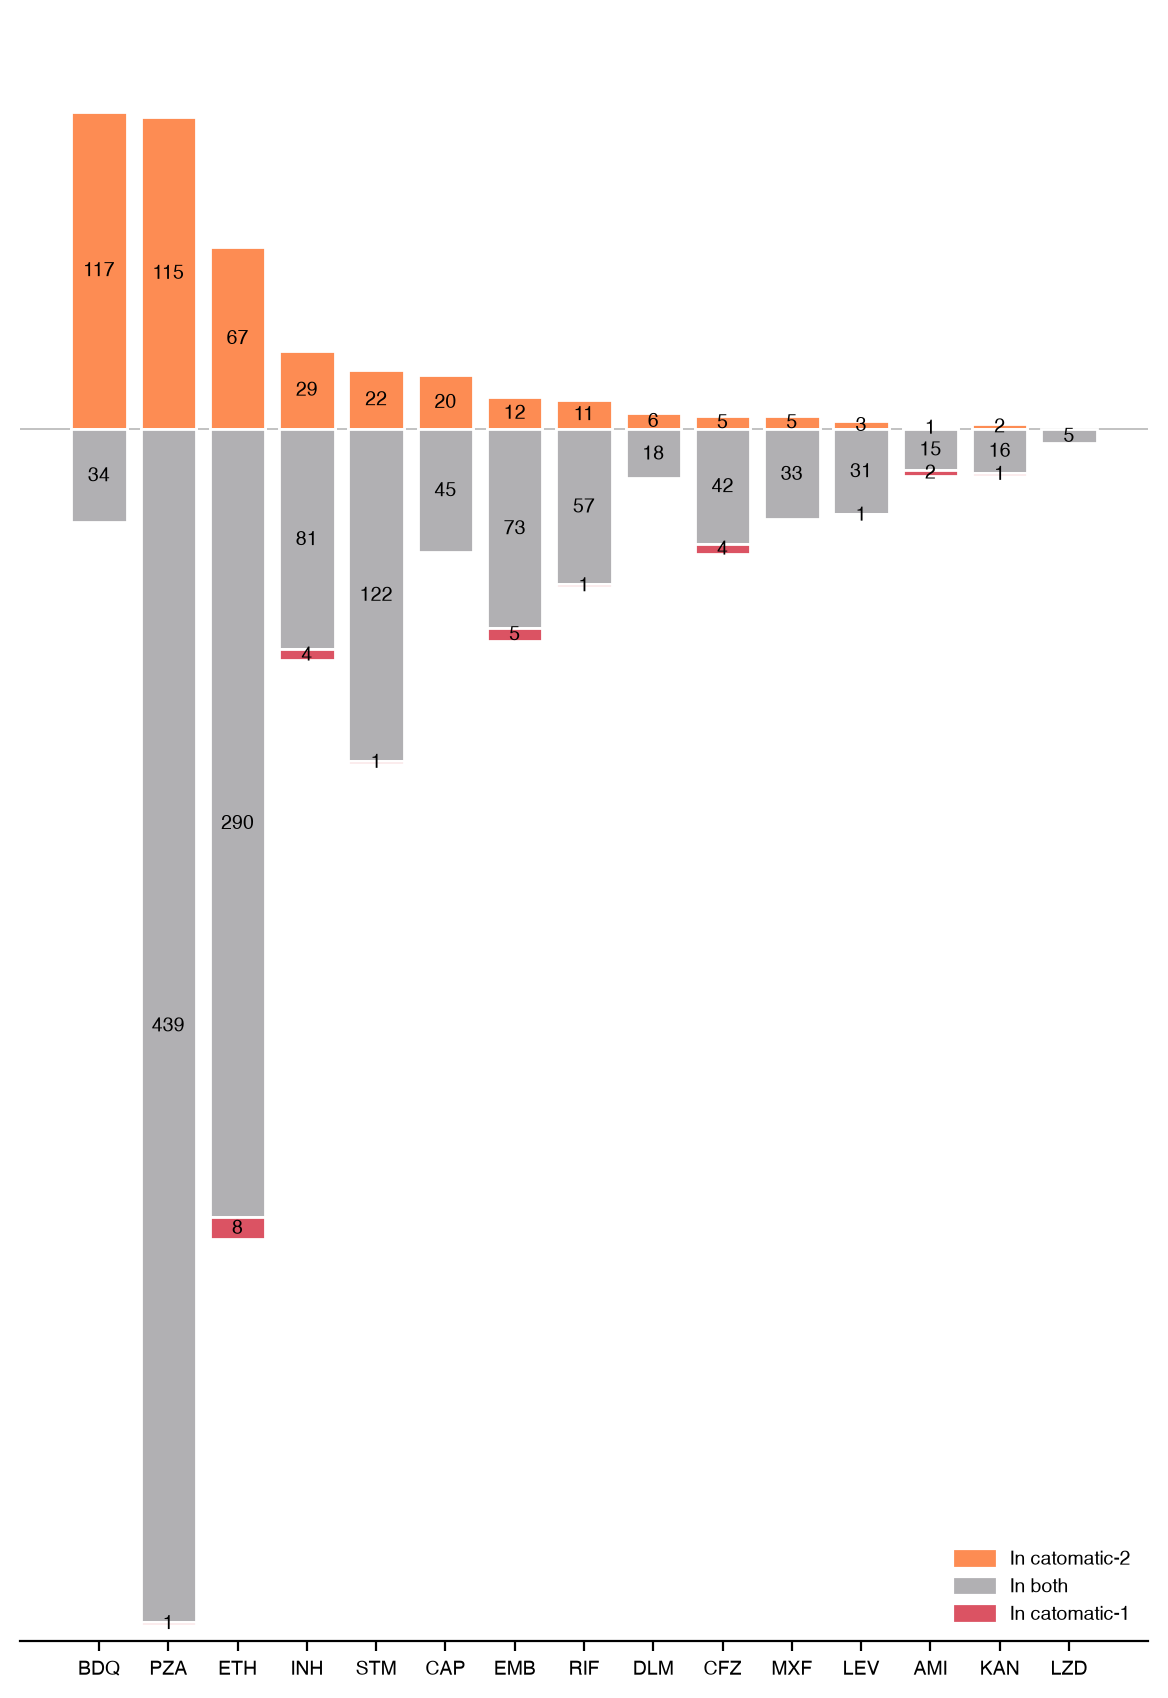

In [ ]:
expanded_catalogues = functions.expand_catalogue_pair(cat, cats_all, valid_drugs, 'RUS', ('cat', 'cats_all'), who_cat=None)
graphs.plot_floating_bars_cat_vs_cats_all(expanded_catalogues, valid_drugs, figsize=(5.85, 8.5), legend=True)


In [ ]:
print ('number of rows more in catalogue trained on all data:', len(cats_all)-len(cat))

number of rows more in catalogue trained on all data: 387


## Mutation comparison for catalogues built at different FRS

In [ ]:
from pathlib import Path
import pandas as pd

def load_frs_catalogue(opt_path, base_path, drug, frs):
    """Load and process one catomatic FRS catalogue for one drug + one FRS value."""
    opt_df = pd.read_csv(opt_path)
    row = opt_df.loc[opt_df['DRUG'].eq(drug)].iloc[0]

    file_path = (
        f"{base_path}/{drug.lower()}/"
        f"bg_{row['BACKGROUND_RATE']}_p_{row['conf_level']}_FRS_{frs}.csv"
    )

    cat_df = pd.read_csv(file_path)

    cat_df['CATALOGUE_VERSION'] = 0
    cat_df['CATALOGUE_NAME'] = '-'

    cat_df['EVIDENCE'] = cat_df['EVIDENCE'].apply(utils.str_to_dict)
    cat_df = cat_df[~cat_df['EVIDENCE'].apply(lambda x: isinstance(x, dict) and 'default_rule' in x)]

    cat_df['solo_R'] = cat_df['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'solo_contingency', 0, 0))
    cat_df['solo_S'] = cat_df['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'solo_contingency', 0, 1))
    cat_df['TOTAL'] = cat_df['solo_R'] + cat_df['solo_S']
    cat_df['PROPORTION'] = cat_df['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'proportion'))
    cat_df['CONFIDENCE'] = cat_df['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'confidence'))

    unknown = cat_df[~cat_df.PREDICTION.isin(['R', 'S'])]
    cat_df = cat_df[cat_df.PREDICTION.isin(['R', 'S'])]

    return cat_df, unknown

In [ ]:
from pathlib import Path

opt_csv = "results/grid_search/opt_cats_MTBC-CRyPTICv1.1.1-2025.8.csv"
base = "./catalogues/MTBC-CRyPTICv1.1.1-2025.8/frs"

opt_df = pd.read_csv(opt_csv)
drugs = opt_df['DRUG'].dropna().unique()

frs_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

frames = []

for drug in drugs:
    for frs in frs_values:
        cat_df, _ = load_frs_catalogue(opt_csv, base, drug, frs)

        cat_df = cat_df[['DRUG', 'MUTATION', 'PREDICTION']].copy()
        cat_df['CATALOGUE'] = f"FRS_{frs}"

        frames.append(cat_df)

long_df = pd.concat(frames, ignore_index=True)

mutation_table = (
    long_df
    .drop_duplicates(['DRUG', 'MUTATION', 'CATALOGUE'])
    .pivot_table(
        index=['DRUG', 'MUTATION'],
        columns='CATALOGUE',
        values='PREDICTION',
        aggfunc='first'
    )
    .fillna('U')
    .sort_index()
    .reset_index()
)
mutation_table.to_csv('./figs/discordance/frs_mutation_comp.csv')
mutation_table

CATALOGUE,DRUG,MUTATION,FRS_0.1,FRS_0.2,FRS_0.3,FRS_0.4,FRS_0.5,FRS_0.6,FRS_0.7,FRS_0.8,FRS_0.9
0,AMI,eis@805_del_ac,S,S,S,S,S,S,S,S,S
1,AMI,eis@E199A,R,R,R,R,R,R,R,R,R
2,AMI,eis@L235R,R,R,R,R,R,R,R,R,R
3,AMI,eis@L331R,R,R,R,R,R,R,R,R,R
4,AMI,eis@V163I,S,S,S,S,S,S,S,S,S
...,...,...,...,...,...,...,...,...,...,...,...
1416,STM,rrs@c513t,R,R,R,R,R,R,R,R,R
1417,STM,rrs@c517t,R,R,R,R,R,R,R,R,R
1418,STM,rrs@c905a,R,R,R,R,R,R,R,R,R
1419,STM,rrs@g878a,R,R,R,R,R,R,R,R,R
